In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline


In [2]:
# 1. Carga y Preparación del Dataset Transversal
df = pd.read_csv('oasis_cross-sectional.csv')

# Selección de atributos predictores
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

# --- LINEAMIENTO: Binarización de CDR (2 Clases) ---
# 0 = "non demented" (CDR 0), 1 = "demented" (CDR >= 0.5)
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

# 2. Tratamiento de Datos Faltantes (SES y Educ)
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)



/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [3]:
# 3. Búsqueda de hiperparámetros para SVM
X_train_tune, X_valid_tune, y_train_tune, y_valid_tune = train_test_split(
    X_prep, y, test_size=0.2, random_state=42, stratify=y
)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, class_weight='balanced', random_state=42))
])

svm_param_grid = [
    {
        'svc__kernel': ['linear', 'rbf'],
        'svc__C': [0.1, 1, 10, 100, 150, 200, 250, 300, 350, 400, 450, 500]
    },
    {
        'svc__kernel': ['rbf', 'linear'],
        'svc__C': [0.1, 1, 10, 100, 150, 200, 250, 300, 350, 400, 450, 500],
        'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10, 100, 1000]
    }
]

svm_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    refit=True
)
svm_search.fit(X_train_tune, y_train_tune)

best_svm_params = svm_search.best_params_
best_svm_kernel = best_svm_params['svc__kernel']
best_svm_C = best_svm_params['svc__C']
best_svm_gamma = best_svm_params.get('svc__gamma', 'scale') if best_svm_kernel == 'rbf' else 'scale'

print('Mejores parámetros SVM encontrados:')
print(svm_search.best_params_)
print(f'Mejor F1 de validación cruzada: {svm_search.best_score_:.4f}')

Mejores parámetros SVM encontrados:
{'svc__C': 300, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Mejor F1 de validación cruzada: 0.8236


Ejecutando 10 iteraciones de validación independiente para SVM...


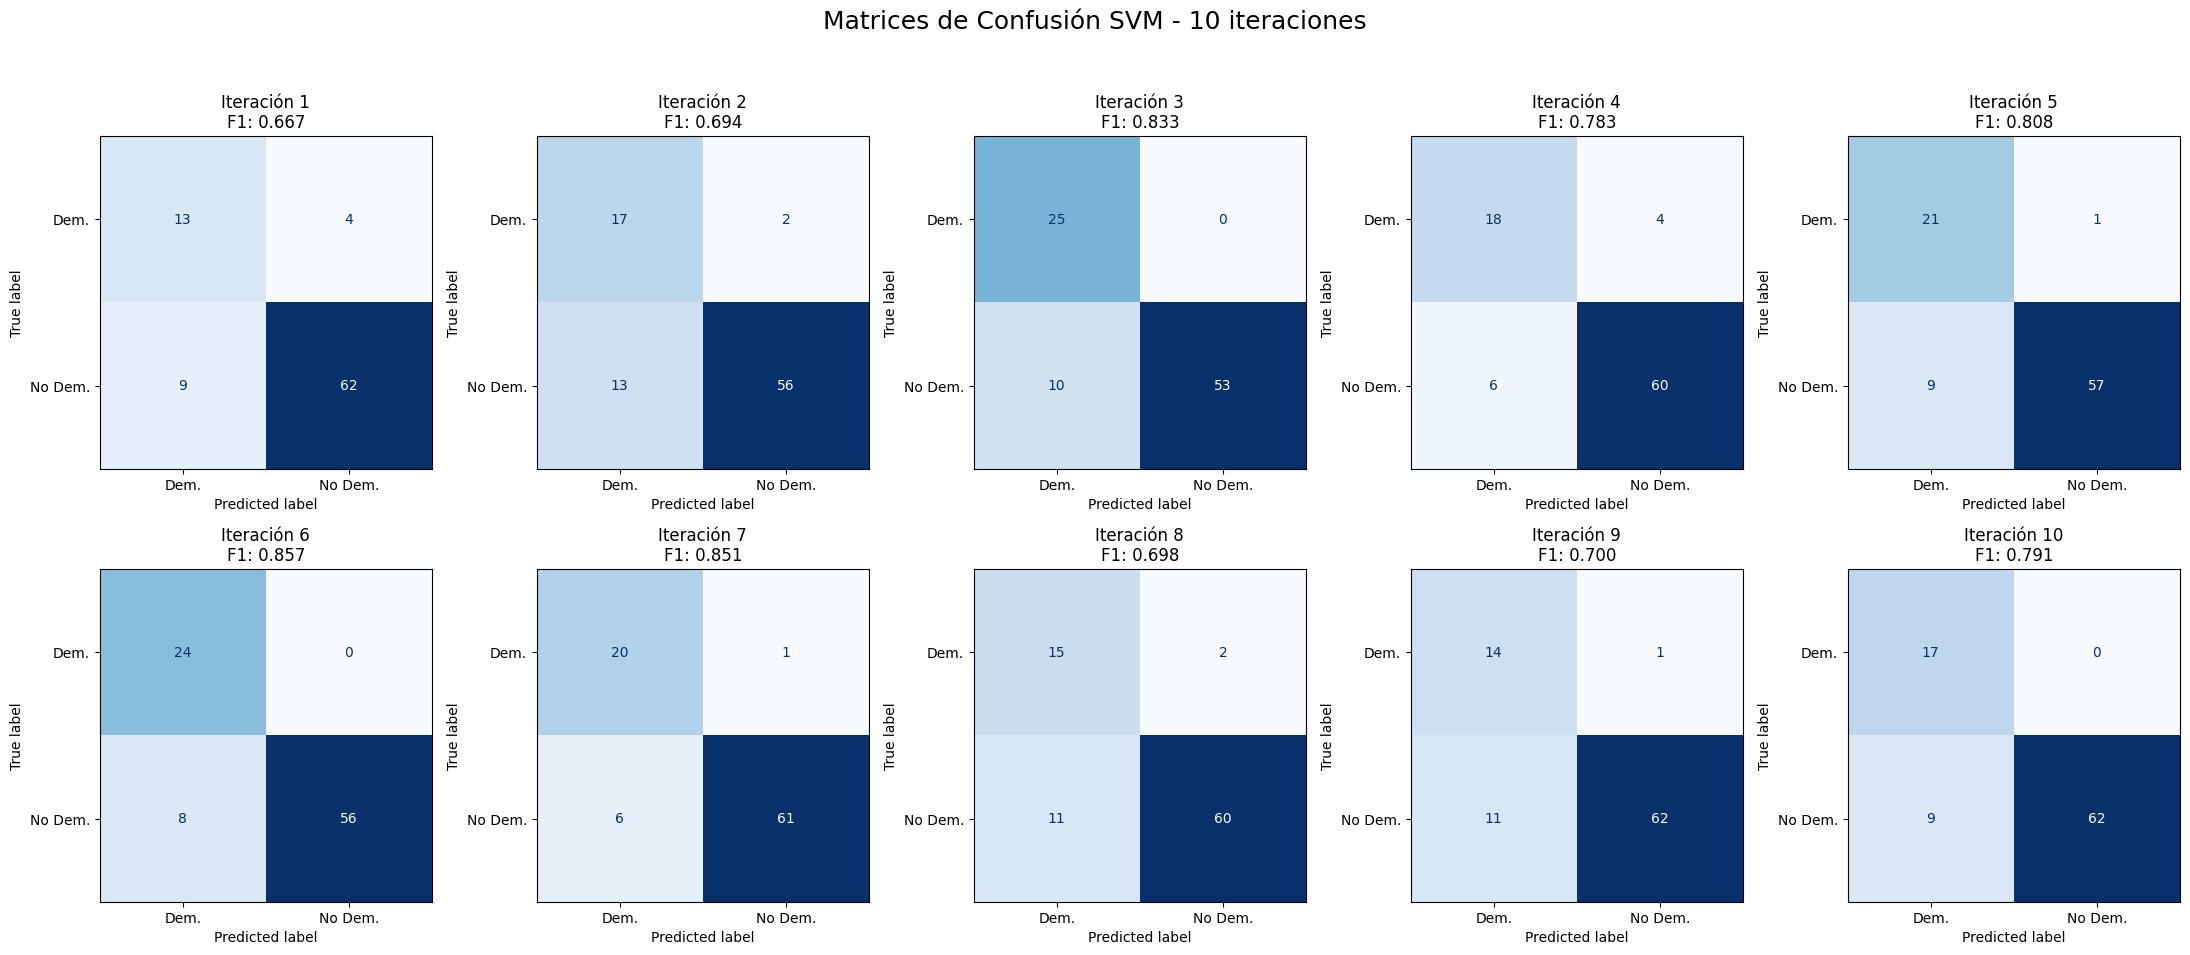

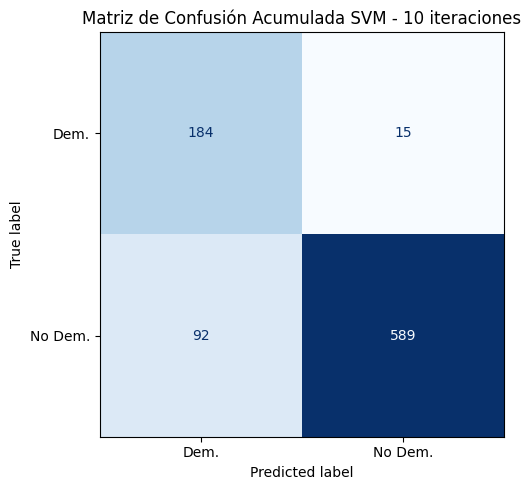


--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.8784 ± 0.0269
PREC                      | 0.6632 ± 0.0794
REC                       | 0.9200 ± 0.0763
F1                        | 0.7681 ± 0.0684
AUC                       | 0.9629 ± 0.0156


In [9]:
# 3. Diseño Experimental: 10 Validaciones Independientes 80/20
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación independiente para SVM...")

for i in range(10):
    # Partición aleatoria única por iteración
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito Crítico para SVM [2]
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 5. Entrenamiento del Modelo SVM
    # kernel, C y gamma se fijan a partir de la búsqueda de hiperparámetros
    svm = SVC(
        kernel=best_svm_kernel,
        C=best_svm_C,
        gamma=best_svm_gamma,
        probability=True,
        class_weight='balanced',
        random_state=42
    )
    svm.fit(X_train_s, y_train)
    
    # Predicciones
    y_pred = svm.predict(X_test_s)
    y_proba = svm.predict_proba(X_test_s)[:, 1]
    
    # 6. Registro de Métricas [5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Matrices de Confusión por iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión SVM - 10 iteraciones", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada SVM - 10 iteraciones')
plt.tight_layout()
plt.show()

# 9. Reporte Final de Desempeño (Media ± DE) [6]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in results:
    print(f"{m.upper():<25} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*55)

Ejecutando 10 iteraciones de validación independiente para SVM...


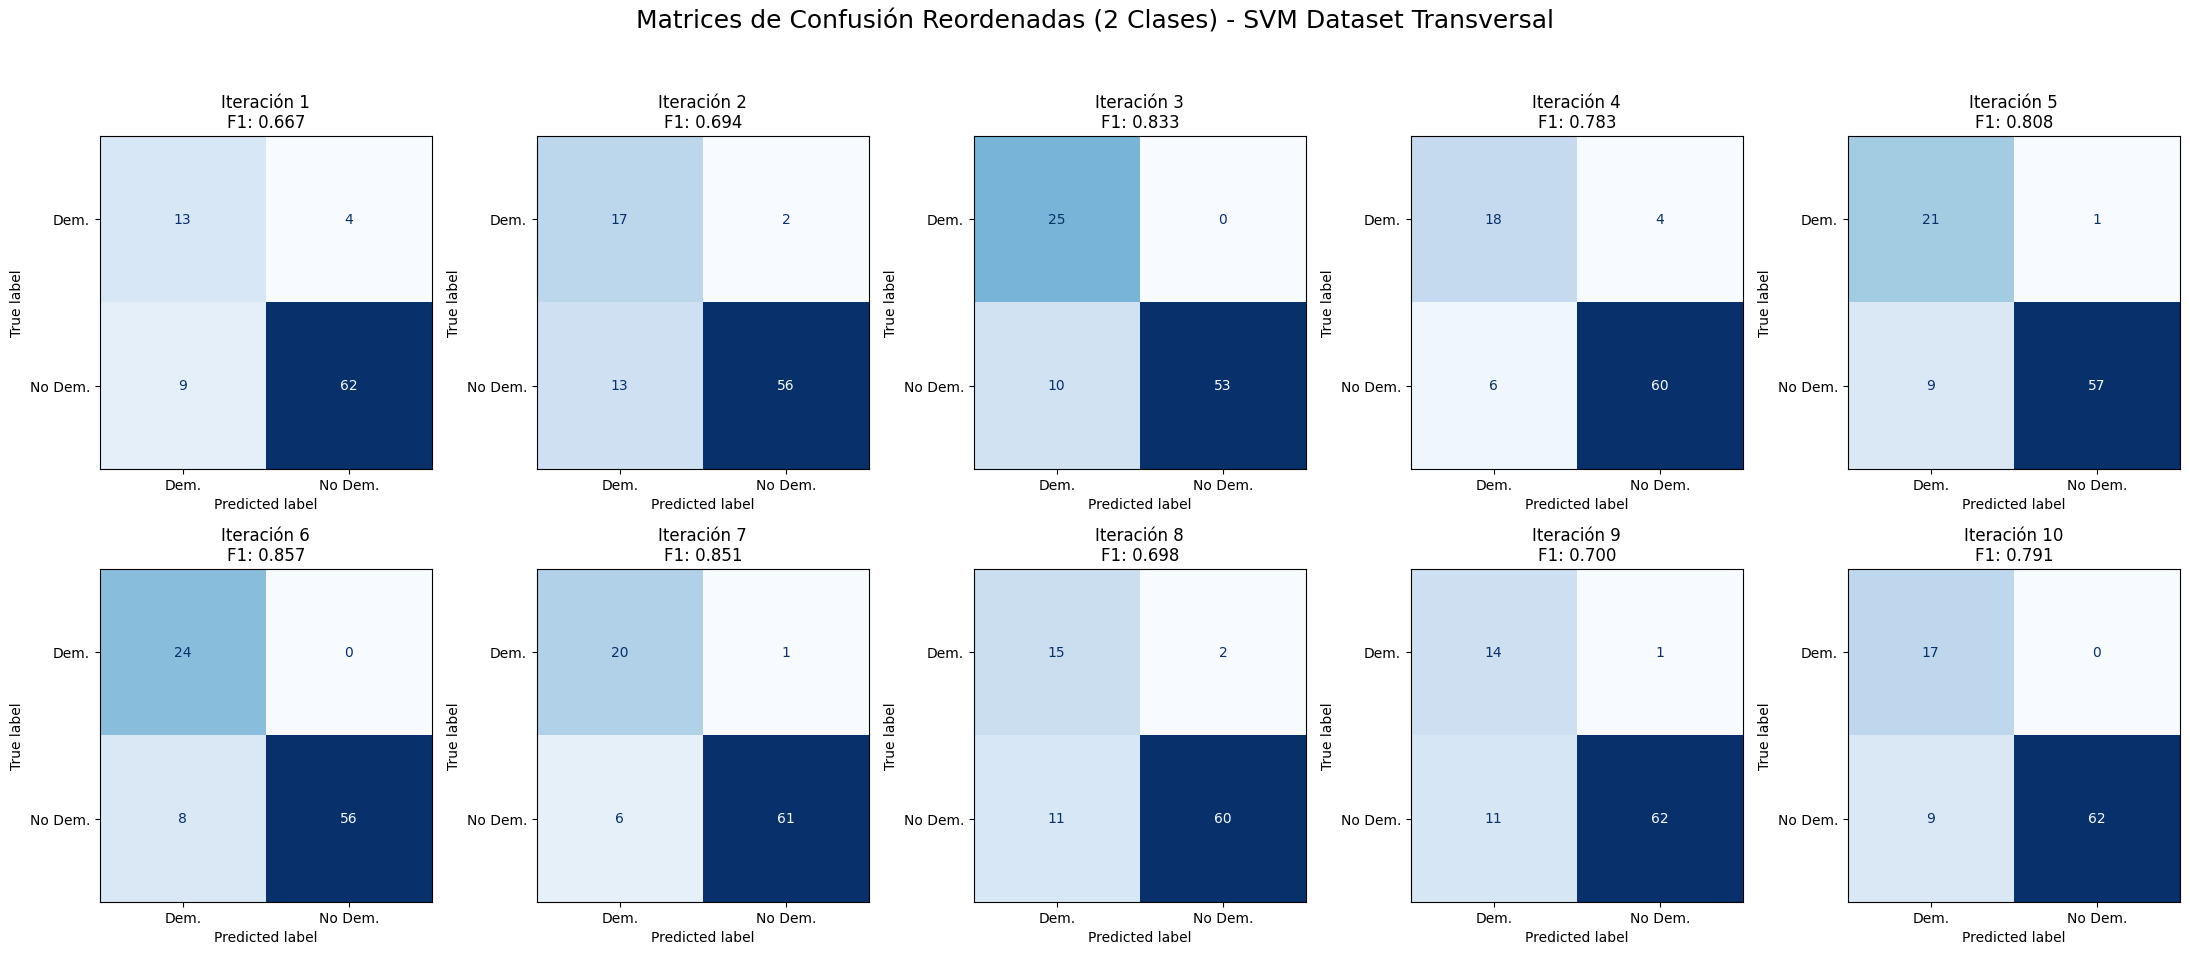

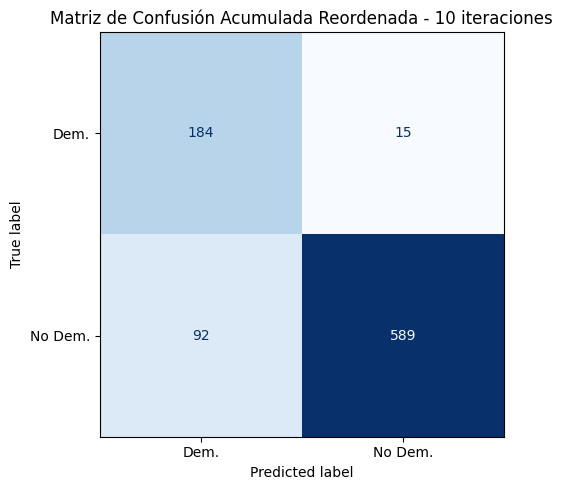


--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.8784 ± 0.0269
PREC                      | 0.6632 ± 0.0794
REC                       | 0.9200 ± 0.0763
F1                        | 0.7681 ± 0.0684
AUC                       | 0.9629 ± 0.0156


In [5]:
# 3. Diseño Experimental: 10 Validaciones Independientes 80/20
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación independiente para SVM...")

for i in range(10):
    # Partición aleatoria única por iteración
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito Crítico para SVM [2]
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 5. Entrenamiento del Modelo SVM
    # kernel, C y gamma se fijan a partir de la búsqueda de hiperparámetros
    svm = SVC(
        kernel=best_svm_kernel,
        C=best_svm_C,
        gamma=best_svm_gamma,
        probability=True,
        class_weight='balanced',
        random_state=42
    )
    svm.fit(X_train_s, y_train)
    
    # Predicciones
    y_pred = svm.predict(X_test_s)
    y_proba = svm.predict_proba(X_test_s)[:, 1]
    
    # 6. Registro de Métricas [5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Matrices de Confusión por iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión Reordenadas (2 Clases) - SVM Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# 9. Reporte Final de Desempeño (Media ± DE) [6]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in results:
    print(f"{m.upper():<25} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*55)

Ejecutando 10 iteraciones de validación independiente para SVM...


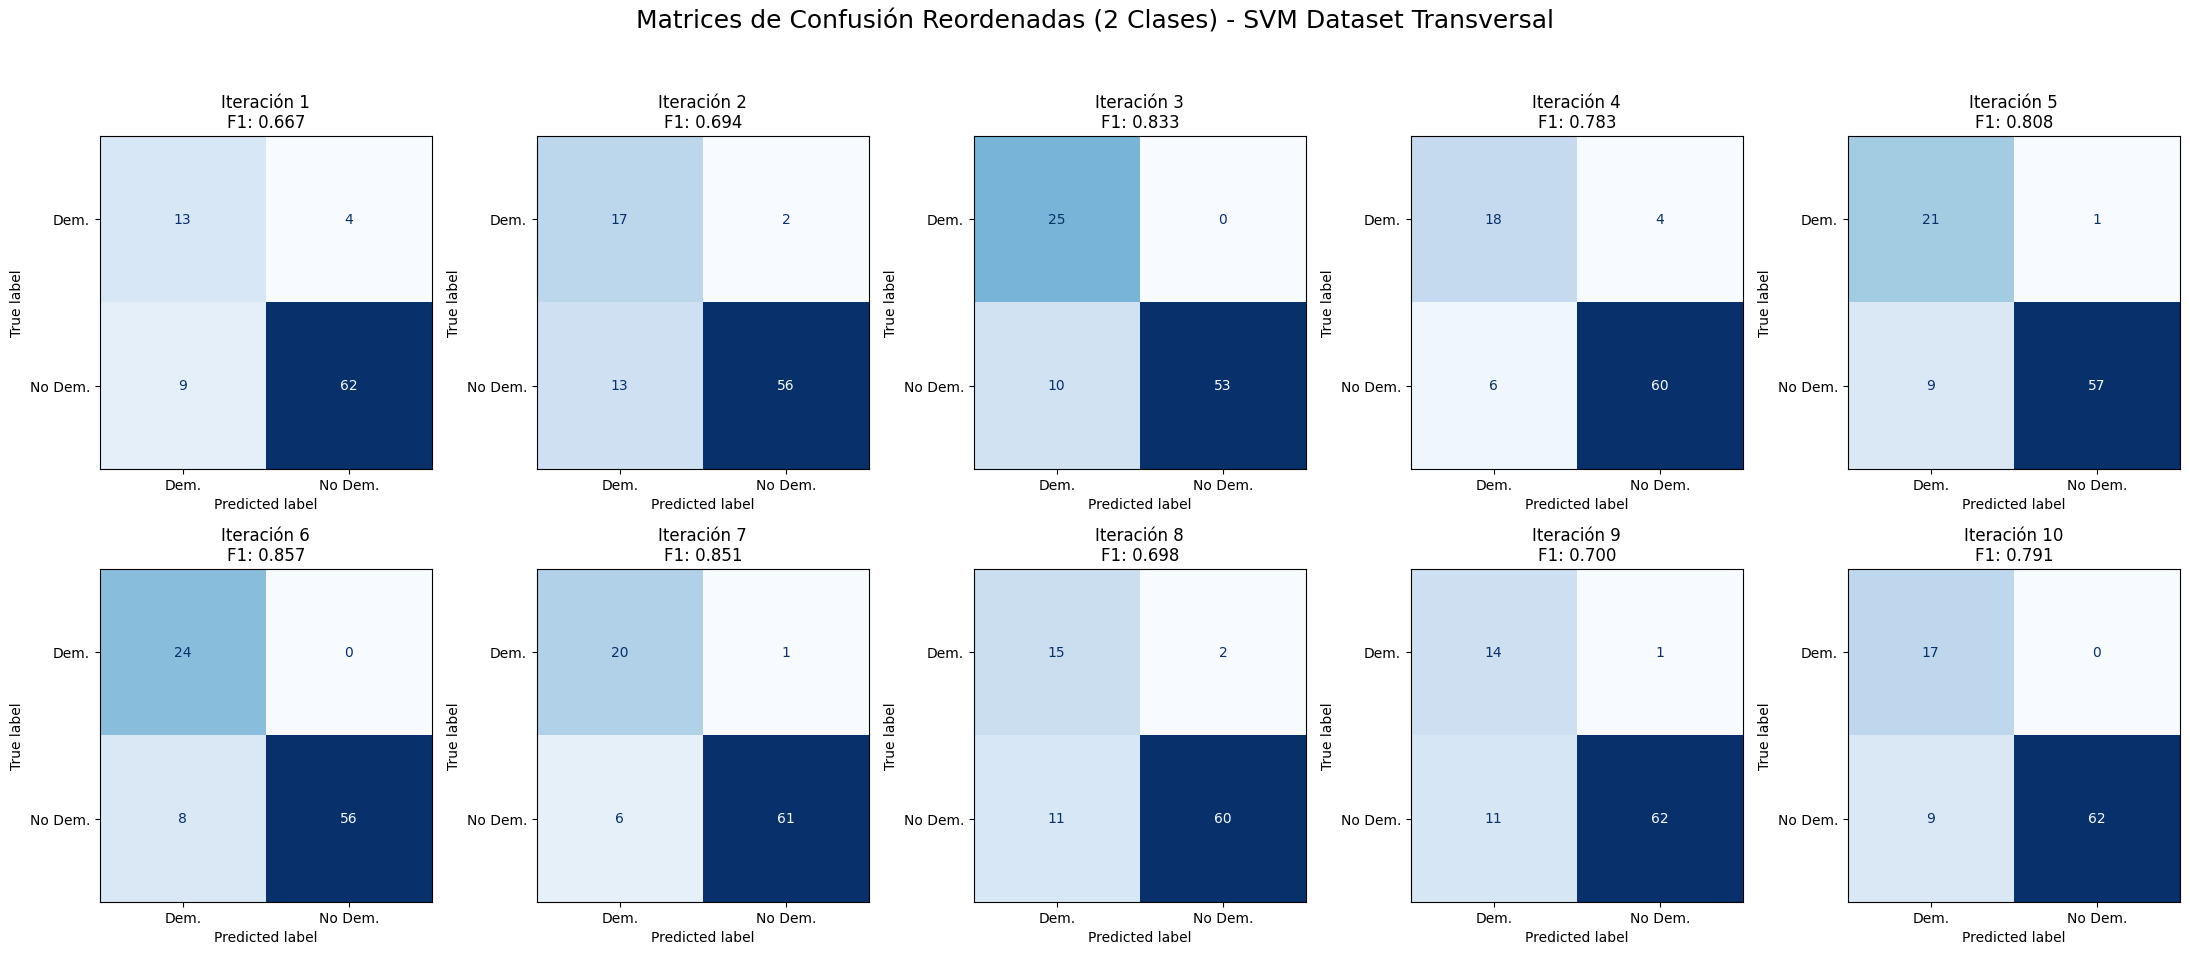

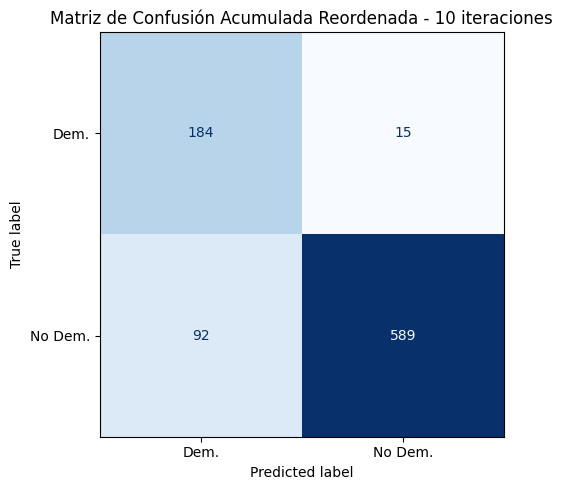


--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.8784 ± 0.0269
PREC                      | 0.6632 ± 0.0794
REC                       | 0.9200 ± 0.0763
F1                        | 0.7681 ± 0.0684
AUC                       | 0.9629 ± 0.0156


In [6]:
# 3. Diseño Experimental: 10 Validaciones Independientes 80/20
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación independiente para SVM...")

for i in range(10):
    # Partición aleatoria única por iteración
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito Crítico para SVM [2]
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 5. Entrenamiento del Modelo SVM
    # kernel, C y gamma se fijan a partir de la búsqueda de hiperparámetros
    svm = SVC(
        kernel=best_svm_kernel,
        C=best_svm_C,
        gamma=best_svm_gamma,
        probability=True,
        class_weight='balanced',
        random_state=42
    )
    svm.fit(X_train_s, y_train)
    
    # Predicciones
    y_pred = svm.predict(X_test_s)
    y_proba = svm.predict_proba(X_test_s)[:, 1]
    
    # 6. Registro de Métricas [5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Matrices de Confusión por iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión Reordenadas (2 Clases) - SVM Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# 9. Reporte Final de Desempeño (Media ± DE) [6]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in results:
    print(f"{m.upper():<25} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*55)

Ejecutando 10 iteraciones de validación independiente para SVM...


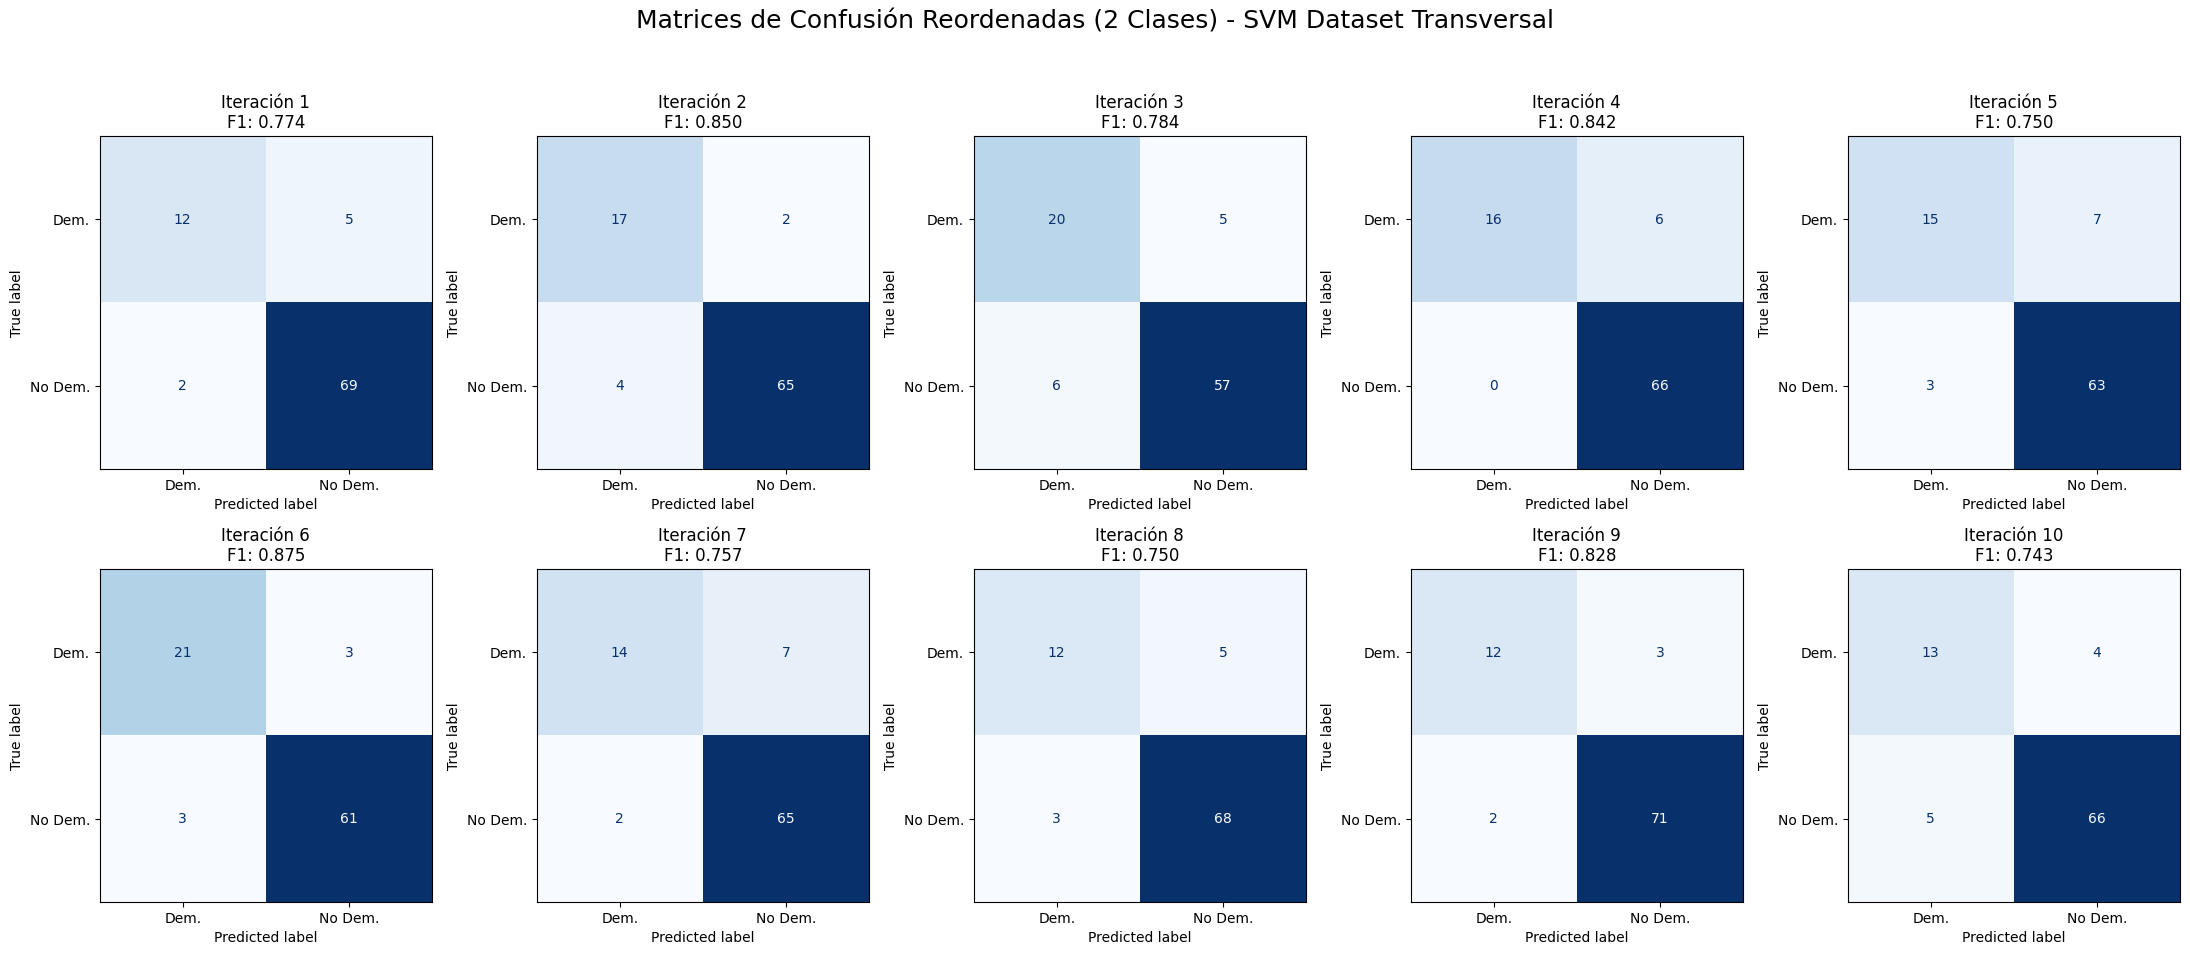

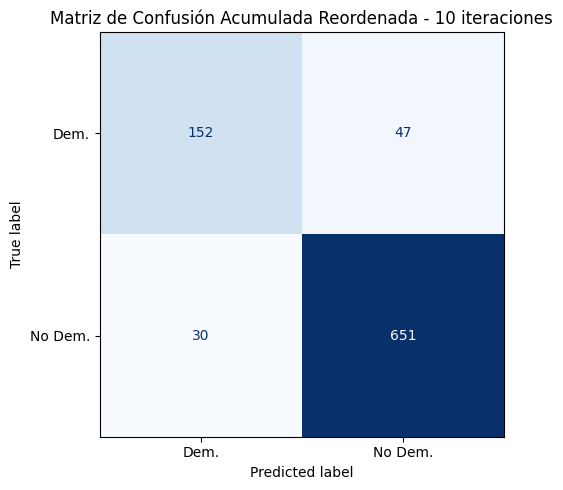


--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.9125 ± 0.0216
PREC                      | 0.8399 ± 0.0708
REC                       | 0.7622 ± 0.0750
F1                        | 0.7953 ± 0.0464
AUC                       | 0.9659 ± 0.0114


In [7]:
# 3. Diseño Experimental: 10 Validaciones Independientes 80/20
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación independiente para SVM...")

for i in range(10):
    # Partición aleatoria única por iteración
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito Crítico para SVM [2]
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 5. Entrenamiento del Modelo SVM
    # kernel, C y gamma se fijan a partir de la búsqueda de hiperparámetros
    svm = SVC(
        kernel=best_svm_kernel,
        C=best_svm_C,
        gamma=best_svm_gamma,
        probability=True,
        random_state=42
    )
    svm.fit(X_train_s, y_train)
    
    # Predicciones
    y_pred = svm.predict(X_test_s)
    y_proba = svm.predict_proba(X_test_s)[:, 1]
    
    # 6. Registro de Métricas [5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Matrices de Confusión por iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión Reordenadas (2 Clases) - SVM Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# 9. Reporte Final de Desempeño (Media ± DE) [6]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in results:
    print(f"{m.upper():<25} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*55)